Laboratorio 5, Fisica Computacional

Juan Manuel Patiño Daza

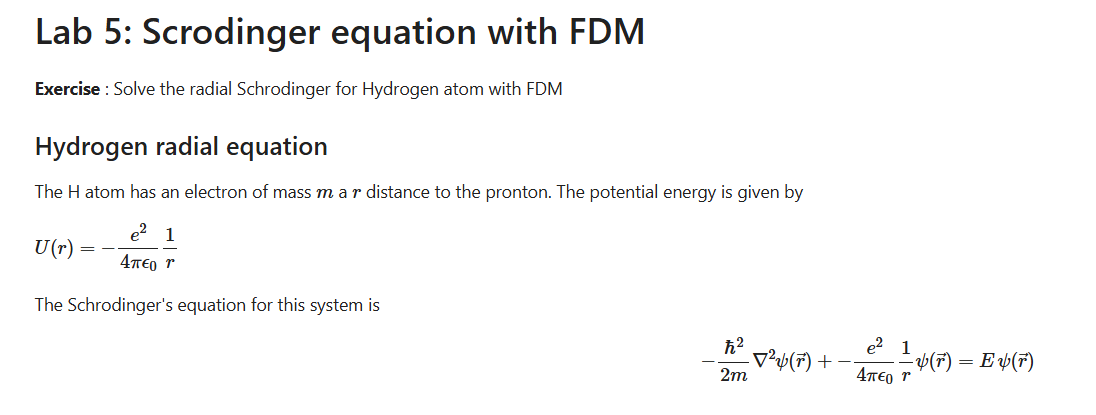

## Ecuación de Schrödinger

Para una partícula de masa $m$ sometida a un potencial $V(\mathbf{r})$, la ecuación de Schrödinger independiente del tiempo es

$$
\hat{H}\psi(\mathbf{r})=E\psi(\mathbf{r}),
$$

$$
-\frac{\hbar^2}{2m}\nabla^2\psi(\mathbf{r})
+
V(\mathbf{r})\psi(\mathbf{r})
=
E\psi(\mathbf{r}).
$$

Debido a la simetría esférica del potencial, es conveniente utilizar
coordenadas esféricas $(r,\theta,\phi)$.

El operador laplaciano en coordenadas esféricas es

$$
\nabla^2
=
\frac{1}{r^2}
\frac{\partial}{\partial r}
\left(
r^2\frac{\partial}{\partial r}
\right)
+
\frac{1}{r^2\sin\theta}
\frac{\partial}{\partial\theta}
\left(
\sin\theta\frac{\partial}{\partial\theta}
\right)
+
\frac{1}{r^2\sin^2\theta}
\frac{\partial^2}{\partial\phi^2}.
$$

Como el potencial depende únicamente de $r$, buscamos una solución
separable de la forma

$$
\psi(r,\theta,\phi)
=
R(r)Y(\theta,\phi).
$$

Al sustituir esta expresión en la ecuación de Schrödinger se obtiene

$$
-\frac{\hbar^2}{2m}
\left[
\frac{1}{r^2}
\frac{d}{dr}
\left(
r^2\frac{dR}{dr}
\right)Y
+
\frac{R}{r^2}\hat{L}_{\Omega}Y
\right]
+
V(r)RY
=
ERY.
$$

Al utilizar la propiedad

$$
\hat{L}_{\Omega}Y_l^m
=
-l(l+1)Y_l^m,
$$

la ecuación de Schrödinger queda

$$
-\frac{\hbar^2}{2m}
\left[
Y_l^m
\frac{d}{dr}
\left(
r^2\frac{dR}{dr}
\right)
-
l(l+1)RY_l^m
\right]
+
r^2V(r)RY_l^m
=
Er^2RY_l^m.
$$

Todos los términos contienen el factor $Y_l^m(\theta,\phi)$:

$$
Y_l^m
\left[
-\frac{\hbar^2}{2m}
\frac{d}{dr}
\left(
r^2\frac{dR}{dr}
\right)
+
\frac{\hbar^2}{2m}l(l+1)R
+
r^2V(r)R
-
Er^2R
\right]
=0.
$$

Como $Y_l^m$ es una función no nula, podemos eliminar el factor
angular y obtener la ecuación radial:

$$
\boxed{
-\frac{\hbar^2}{2m}
\frac{d}{dr}
\left(
r^2\frac{dR}{dr}
\right)
+
\frac{\hbar^2}{2m}l(l+1)R
+
r^2V(r)R
=
Er^2R
}
$$

## Aproximación por diferencias finitas

Se discretiza la coordenada radial mediante una malla

$$
r_i=i\Delta r,
\qquad i=0,1,2,\ldots,N.
$$

En cada punto de la malla aproximamos la función continua mediante

$$
u_i=u(r_i).
$$

La segunda derivada se aproxima mediante la diferencia central:

$$
\boxed{
\frac{d^2u}{dr^2}\bigg|_{r_i}
\approx
\frac{u_{i+1}-2u_i+u_{i-1}}
{(\Delta r)^2}
}
$$

## Ecuación radial

Sustituyendo $R=u/r$ en la ecuación radial obtenemos

$$
-\frac{\hbar^2}{2m}
r\frac{d^2u}{dr^2}
+
\frac{\hbar^2}{2m}
\frac{l(l+1)}{r}u
+
rV(r)u
=
Er u.
$$

Dividiendo por $r$:

$$
\boxed{
-\frac{\hbar^2}{2m}
\frac{d^2u}{dr^2}
+
\left[
V(r)
+
\frac{\hbar^2l(l+1)}{2mr^2}
\right]u
=
Eu
}
$$

Esta es la ecuación radial que se utilizará para aplicar el método de
diferencias finitas.

## Potencial efectivo

Podemos definir el potencial efectivo como

$$
\boxed{
V_{\mathrm{eff}}(r)
=
V(r)
+
\frac{\hbar^2l(l+1)}{2mr^2}
}
$$

y para el átomo de hidrógeno:

$$
\boxed{
V_{\mathrm{eff}}(r)
=
-\frac{e^2}{4\pi\varepsilon_0r}
+
\frac{\hbar^2l(l+1)}{2mr^2}
}
$$

Por tanto, la ecuación radial adquiere la forma

$$
\boxed{
-\frac{\hbar^2}{2m}
\frac{d^2u}{dr^2}
+
V_{\mathrm{eff}}(r)u
=
Eu
}
$$

Esta ecuación tiene la misma estructura que una ecuación de Schrödinger
unidimensional, por lo que ahora puede resolverse mediante diferencias
finitas.

pero en nuestro caso l es igual a 0 entonces el Veff es el mismo V que ya nos da el problema

## Discretización de la ecuación de Schrödinger

Partimos de

$$
-\frac{\hbar^2}{2m}
\frac{d^2u}{dr^2}
+
V_{\mathrm{eff}}(r)u
=
Eu.
$$

Aplicando la aproximación de diferencias finitas:

$$
-\frac{\hbar^2}{2m}
\frac{
u_{i+1}-2u_i+u_{i-1}
}{
(\Delta r)^2
}
+
V_{\mathrm{eff}}(r_i)u_i
=
Eu_i.
$$

Definimos

$$
t=
\frac{\hbar^2}{2m(\Delta r)^2}.
$$

Entonces

$$
-t(u_{i+1}-2u_i+u_{i-1})
+
V_{\mathrm{eff}}(r_i)u_i
=
Eu_i.
$$

Reordenando:

$$
\boxed{
-tu_{i-1}
+
\left[
2t+V_{\mathrm{eff}}(r_i)
\right]u_i
-tu_{i+1}
=
Eu_i
}
$$

## Construcción de la matriz Hamiltoniana

La ecuación anterior se aplica en cada punto de la malla. Por ejemplo,

$$
-tu_{i-1}
+
(2t+V_i)u_i
-tu_{i+1}
=
Eu_i.
$$

Por tanto, la matriz Hamiltoniana tiene la estructura tridiagonal

$$
\boxed{
H=
\begin{pmatrix}
2t+V_1 & -t & 0 & 0 & \cdots\\
-t & 2t+V_2 & -t & 0 & \cdots\\
0 & -t & 2t+V_3 & -t & \cdots\\
0 & 0 & -t & 2t+V_4 & \cdots\\
\vdots & \vdots & \vdots & \vdots & \ddots
\end{pmatrix}
}
$$

y el problema numérico queda

$$
\boxed{
H\mathbf{u}=E\mathbf{u}.
}
$$

Los valores propios $E_n$ corresponden a las energías permitidas,
mientras que los vectores propios $\mathbf{u}_n$ representan los
estados radiales discretizados.

In [1]:
#librerias
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

In [2]:
#costantes del problema
N = 1000
R = 50
r = np.linspace(0.01, R, N)
dr = r[1] - r[0]

#esta funcion la definimos solamente para no tener que modificar cosas si cambiamos el l
def R(l):
  U = -1/r + ((l*(l+1))/(2* (r**2)))
  t = 1/(2*dr**2)

  V = np.zeros((N, N))
  V[0,0] = 2*t + U[0]

  for i in range(1,N):
      V[i,i] = 2*t + U[i]
      V[i,i-1] = -t
      V[i-1,i] = -t
  return V


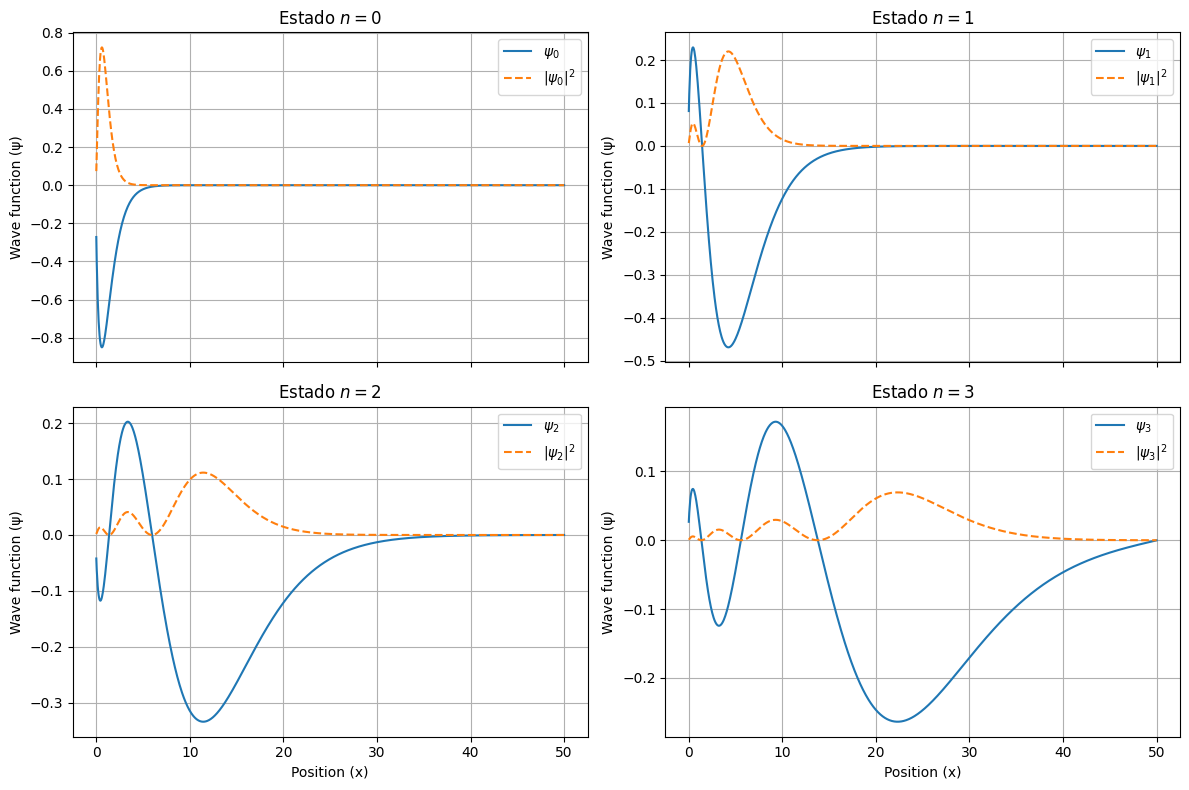

In [3]:
V = R(0) #usamos un l = 0
E, psi = np.linalg.eigh(V)  #solucion de problemas de valores propios

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for estado in range(4):
    ax = axes[estado]

    area_trap = np.trapezoid(psi.T[estado] ** 2, x=r)
    psi_norm = psi.T[estado] / np.sqrt(area_trap)

    ax.plot(r, psi_norm, label=f"$\\psi_{{{estado}}}$")
    ax.plot(r, psi_norm**2, label=f"$|\\psi_{{{estado}}}|^2$", linestyle="--")

    ax.set_title(f"Estado $n = {estado}$")
    ax.set_ylabel("Wave function (ψ)")
    ax.grid(True)
    ax.legend(loc="upper right")

axes[2].set_xlabel("Position (x)")
axes[3].set_xlabel("Position (x)")
plt.tight_layout()
plt.show()

* en el grafico anterior apreciamos los primeros 4 estados teniendo como numero cuantico, l=0, ademas usamos unidades atomicas por lo cual la ecuacion se simplifica mucho y el calculo es astante corto

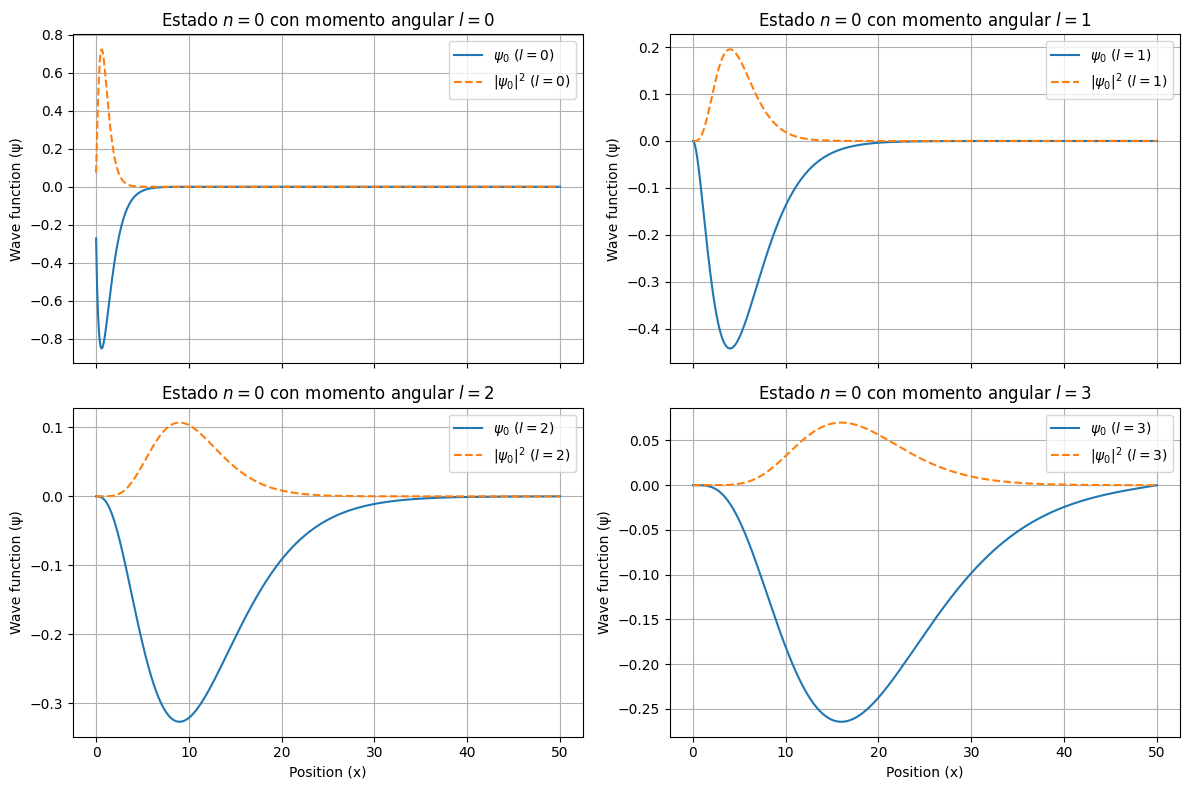

In [5]:
estado = 0  #n = 0

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i in range(0,4):
    ax = axes[i]

    # Cálculo de la matriz y diagonalización para cada l
    V = R(i)
    E, psi = np.linalg.eigh(V)

    # Normalización para el estado 0
    area_trap = np.trapezoid(psi.T[estado] ** 2, x=r)
    psi_norm = psi.T[estado] / np.sqrt(area_trap)

    ax.plot(r, psi_norm, label=rf"$\psi_{0}$ ($l={i}$)")
    ax.plot(r, psi_norm**2, label=rf"$|\psi_{0}|^2$ ($l={i}$)", linestyle="--")
    ax.set_title(f"Estado $n = 0$ con momento angular $l = {i}$")
    ax.set_ylabel("Wave function (ψ)")
    ax.grid(True)
    ax.legend(loc="upper right")

axes[2].set_xlabel("Position (x)")
axes[3].set_xlabel("Position (x)")

plt.tight_layout()
plt.show()

se realizan 4 graficos mas pero modificando el l manteniendo el mismo estado n